# Is MIT's Post-Graduation Earnings Statistically Exceptional?

#### What is the z-score for the median post-graduate income of MIT relative to other US universities, and is this z-score in the upper 2.5% of all schools?

#### This is an observational study. All data regarding income, admissions, and school statistics have been previously collected and measured (e.g., on the US Department of Education's College Scorecard). We cannot assign a condition to any of the schools or manipulate a variable. We can only describe an association/standing.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (9, 5.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('cleaned_college.csv').copy()
print(f"Rows: {len(df):,}   Columns: {len(df.columns)}")
df[['school_id', 'school_name', 'city', 'state', 'median_earnings_10yrs']].head()


Rows: 6,273   Columns: 124


,school_id,school_name,city,state,median_earnings_10yrs
0,100654,Alabama A & M University,Normal,AL,40628.0
1,100663,University of Alabama at Birmingham,Birmingham,AL,54501.0
2,100690,Amridge University,Montgomery,AL,37621.0
3,100706,University of Alabama in Huntsville,Huntsville,AL,61767.0
4,100724,Alabama State University,Montgomery,AL,34502.0


In [2]:

EARNINGS_COL = 'median_earnings_10yrs'

n_total = len(df)
n_missing = df[EARNINGS_COL].isna().sum()

earnings = df[EARNINGS_COL].dropna()

print(f"Total schools in dataset:         {n_total:,}")
print(f"Schools missing earnings data:    {n_missing:,}")
print(f"Schools with usable earnings data: {len(earnings):,}")


Total schools in dataset:         6,273
Schools missing earnings data:    1,146
Schools with usable earnings data: 5,127


In [3]:

mean_earnings = earnings.mean()
std_earnings = earnings.std(ddof=0)

print(f"Mean median 10-yr earnings across schools: ${mean_earnings:,.2f}")
print(f"Standard deviation:                        ${std_earnings:,.2f}")

df['earnings_zscore'] = (df[EARNINGS_COL] - mean_earnings) / std_earnings


Mean median 10-yr earnings across schools: $43,793.97
Standard deviation:                        $17,130.61


In [4]:

mit_mask = df['school_name'].str.contains('Massachusetts Institute of Technology', case=False, na=False)
mit = df[mit_mask]

assert len(mit) == 1, f"Expected exactly one match, found {len(mit)}"
mit_row = mit.iloc[0]

mit_earnings = mit_row[EARNINGS_COL]
mit_z = mit_row['earnings_zscore']

print(f"School:                 {mit_row['school_name']} ({mit_row['city']}, {mit_row['state']})")
print(f"Median earnings (10yr): ${mit_earnings:,.0f}")
print(f"Dataset mean:           ${mean_earnings:,.2f}")
print(f"Dataset std dev:        ${std_earnings:,.2f}")
print(f"Z-score:                {mit_z:.3f}")


School:                 Massachusetts Institute of Technology (Cambridge, MA)
Median earnings (10yr): $143,372
Dataset mean:           $43,793.97
Dataset std dev:        $17,130.61
Z-score:                5.813


In [5]:

threshold = 2.0
in_top_2_5_pct = mit_z > threshold

implied_tail_prob = 1 - stats.norm.cdf(mit_z)

empirical_percentile = stats.percentileofscore(earnings, mit_earnings)
rank = int((earnings > mit_earnings).sum() + 1)

print(f"Z-score threshold for top 2.5%:        {threshold}")
print(f"MIT's z-score:                         {mit_z:.3f}")
print(f"Is MIT's z-score > 2.0?                 {in_top_2_5_pct}")
print(f"Normal-model tail probability (z > mit_z): {implied_tail_prob:.2e}")
print(f"Empirical percentile (actual data):    {empirical_percentile:.2f}th percentile")
print(f"MIT's rank by earnings:                #{rank} out of {len(earnings)} schools")


Z-score threshold for top 2.5%:        2.0
MIT's z-score:                         5.813
Is MIT's z-score > 2.0?                 True
Normal-model tail probability (z > mit_z): 3.07e-09
Empirical percentile (actual data):    100.00th percentile
MIT's rank by earnings:                #1 out of 5127 schools


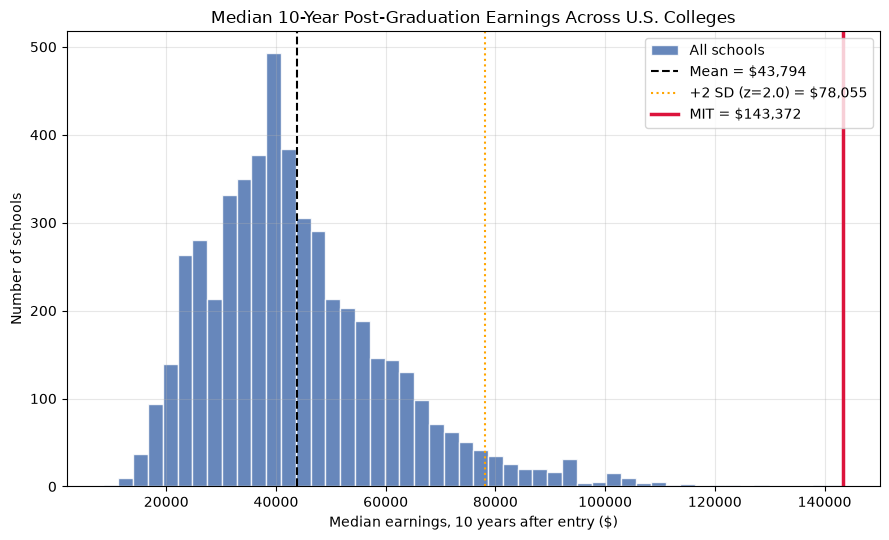

In [6]:

fig, ax = plt.subplots()

ax.hist(earnings, bins=50, color='#4C72B0', edgecolor='white', alpha=0.85, label='All schools')
ax.axvline(mean_earnings, color='black', linestyle='--', linewidth=1.5, label=f'Mean = ${mean_earnings:,.0f}')
ax.axvline(mean_earnings + 2*std_earnings, color='orange', linestyle=':', linewidth=1.5,
           label=f'+2 SD (z=2.0) = ${mean_earnings + 2*std_earnings:,.0f}')
ax.axvline(mit_earnings, color='crimson', linewidth=2.5, label=f'MIT = ${mit_earnings:,.0f}')

ax.set_title('Median 10-Year Post-Graduation Earnings Across U.S. Colleges')
ax.set_xlabel('Median earnings, 10 years after entry ($)')
ax.set_ylabel('Number of schools')
ax.legend()
plt.tight_layout()
plt.show()


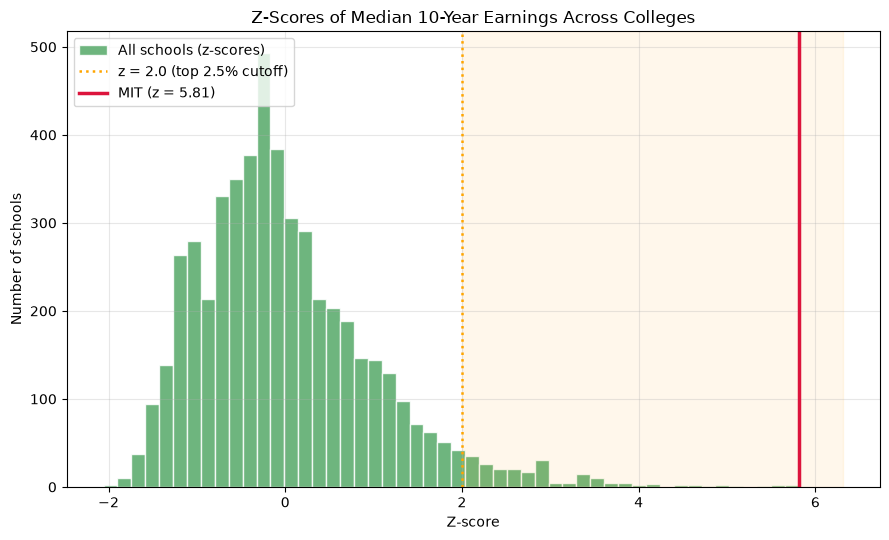

In [7]:

z_scores = df['earnings_zscore'].dropna()

fig, ax = plt.subplots()

ax.hist(z_scores, bins=50, color='#55A868', edgecolor='white', alpha=0.85, label='All schools (z-scores)')
ax.axvline(2.0, color='orange', linestyle=':', linewidth=1.8, label='z = 2.0 (top 2.5% cutoff)')
ax.axvline(mit_z, color='crimson', linewidth=2.5, label=f'MIT (z = {mit_z:.2f})')
ax.axvspan(2.0, z_scores.max() + 0.5, color='orange', alpha=0.08)

ax.set_title('Z-Scores of Median 10-Year Earnings Across Colleges')
ax.set_xlabel('Z-score')
ax.set_ylabel('Number of schools')
ax.legend()
plt.tight_layout()
plt.show()



## 8. Conclusion

Ten years after graduation, the annual income of MIT graduates is about $143,372 while the mean salary for graduates across America is $43,794. Thus, the z score of MIT is 5.81. Since 5.81 is very much greater than 2.0, MIT is clearly within the top 2.5 percent of all colleges. In point of fact, MIT came out on top among all the colleges.